# Notebook 03 — Inference, Evaluation & Interpretation

Using the two fitted Bayesian networks from notebook 02, this notebook:

1. Runs **exact inference** (Variable Elimination) to get posterior probabilities P(target=1 | observed features).
2. Evaluates prediction quality: **accuracy, ROC-AUC, Brier score**.
3. Plots **calibration curves** — the distinguishing quality of a probabilistic model.
4. Runs **5-fold stratified cross-validation** to assess generalisation.
5. Analyses model **sensitivity** via Markov-blanket ablation.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.inference import VariableElimination

from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold

plt.rcParams['figure.dpi'] = 110
SEED = 179
print('All imports OK')

All imports OK


## 2. Load data and models

In [2]:
train_df = pd.read_csv('heart_train.csv').astype(str)
test_df  = pd.read_csv('heart_test.csv').astype(str)
full_df  = pd.read_csv('heart_discretized.csv').astype(str)

with open('expert_model.pkl',  'rb') as f:
    expert_model  = pickle.load(f)
with open('learned_model.pkl', 'rb') as f:
    learned_model = pickle.load(f)

FEATURES = [c for c in train_df.columns if c != 'target']
print(f'Test set: {len(test_df)} rows')

Test set: 61 rows


## 3. Inference helper

We use **Variable Elimination** with the `MinFill` elimination order for efficiency. For each patient we query P(target | all other features observed).

In [3]:
def predict_proba_bn(model, data, target='target'):
    ie = VariableElimination(model)
    features = [c for c in data.columns if c != target and c in model.nodes()]
    
    probs = []
    for _, row in data.iterrows():
        evidence = {col: row[col] for col in features}
        try:
            q = ie.query([target], evidence=evidence, elimination_order='MinFill', show_progress=False)
            idx = list(q.state_names[target]).index('1')
            prob = float(q.values[idx])
        except Exception:
            prob = 0.5
        probs.append(prob)
        
    return np.array(probs)

print('Running inference on test set (expert model) ...')
expert_proba  = predict_proba_bn(expert_model,  test_df)
print('Running inference on test set (learned model) ...')
learned_proba = predict_proba_bn(learned_model, test_df)

y_test = test_df['target'].astype(int).values
print(f'Done. Test-set positives: {y_test.mean():.1%}')

Running inference on test set (expert model) ...
Running inference on test set (learned model) ...
Done. Test-set positives: 54.1%


## 4. Point-prediction metrics

In [4]:
def eval_metrics(y_true, proba, label):
    pred = (proba >= 0.5).astype(int)
    acc  = accuracy_score(y_true, pred)
    auc  = roc_auc_score(y_true, proba)
    brier = brier_score_loss(y_true, proba)
    print(f'{label:20s}  Accuracy={acc:.3f}  ROC-AUC={auc:.3f}  Brier={brier:.3f}')
    return dict(label=label, acc=acc, auc=auc, brier=brier, pred=pred, proba=proba)

r_expert  = eval_metrics(y_test, expert_proba,  'Expert DAG')
r_learned = eval_metrics(y_test, learned_proba, 'Learned DAG (HC/BIC)')

Expert DAG            Accuracy=0.574  ROC-AUC=0.683  Brier=0.221
Learned DAG (HC/BIC)  Accuracy=0.869  ROC-AUC=0.919  Brier=0.110


## 5. Confusion matrices

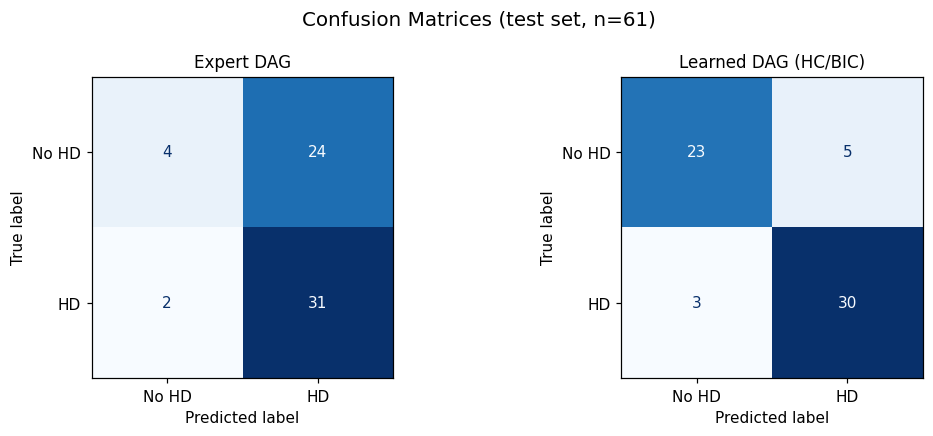

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, r in zip(axes, [r_expert, r_learned]):
    cm = confusion_matrix(y_test, r['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No HD', 'HD'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['label'], fontsize=11)

plt.suptitle('Confusion Matrices (test set, n=61)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. ROC curves

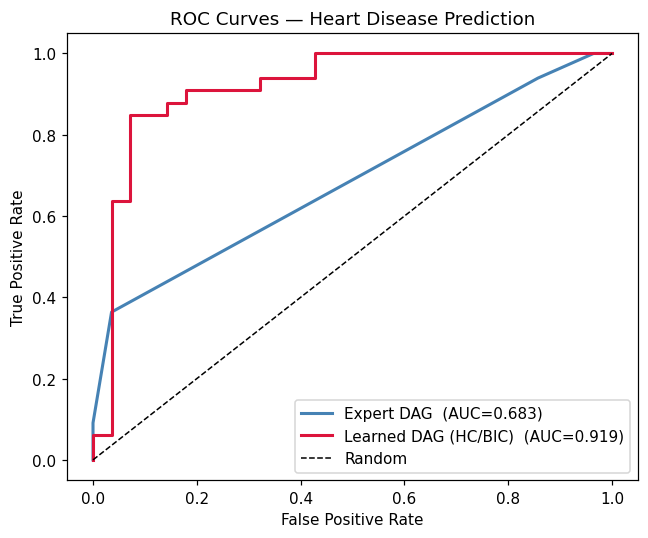

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

for r, color in [(r_expert, 'steelblue'), (r_learned, 'crimson')]:
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{r['label']}  (AUC={r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Heart Disease Prediction')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Calibration curves

A probabilistic model should report confidence that matches empirical frequency. A **perfectly calibrated** model lies on the diagonal. The Brier score quantifies calibration + resolution jointly.

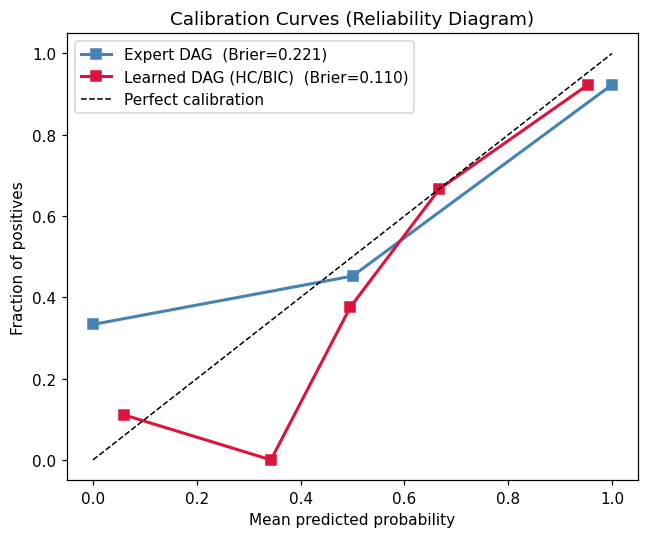

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

for r, color in [(r_expert, 'steelblue'), (r_learned, 'crimson')]:
    # n_bins=5 because test set is small (n=61)
    frac_pos, mean_pred = calibration_curve(y_test, r['proba'], n_bins=5, strategy='uniform')
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=2, ms=7,
            label=f"{r['label']}  (Brier={r['brier']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curves (Reliability Diagram)')
ax.legend()
plt.tight_layout()
plt.savefig('calibration_curves.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. 5-fold stratified cross-validation

The test set has only 61 rows. We run 5-fold CV on the full discretised dataset (n=303) to get a more stable estimate of generalisation.

In [8]:
def cv_bayesian_network(edges_fn, data, n_splits=5, seed=SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_all = data['target'].astype(int).values
    accs, aucs, briers = [], [], []
    
    # Pre-compute all possible states from the FULL dataset
    all_states = {col: sorted(list(data[col].unique())) for col in data.columns}

    # FIX: Pass state_names directly into the estimator here
    bdeu = DiscreteBayesianEstimator(
        prior_type='BDeu', 
        equivalent_sample_size=5,
        state_names=all_states
    )

    for fold, (tr_idx, te_idx) in enumerate(skf.split(data, y_all), 1):
        tr = data.iloc[tr_idx].reset_index(drop=True)
        te = data.iloc[te_idx].reset_index(drop=True)
        y_te = te['target'].astype(int).values

        edges = edges_fn(tr)
        model = DiscreteBayesianNetwork(edges)

        # Revert to your clean .fit() wrapper
        model.fit(tr, estimator=bdeu)

        proba = predict_proba_bn(model, te)
        
        accs.append(accuracy_score(y_te, (proba >= 0.5).astype(int)))
        aucs.append(roc_auc_score(y_te, proba))
        briers.append(brier_score_loss(y_te, proba))

        print(f' Fold {fold}: acc={accs[-1]:.3f} auc={aucs[-1]:.3f} brier={briers[-1]:.3f}')

    return np.array(accs), np.array(aucs), np.array(briers)

# Expert: fixed edges regardless of fold data
expert_edges_fn = lambda tr: EXPERT_EDGES

# Learned: re-run HC search on each training fold
def learned_edges_fn(tr):
    hc = HillClimbSearch(tr)
    dag = hc.estimate(scoring_method='bic-d',
                      max_indegree=3, max_iter=int(1e4), show_progress=False)
    return list(dag.edges())

EXPERT_EDGES = [
    ('age', 'trestbps'), ('age', 'chol'),  ('age', 'thalach'),
    ('sex', 'chol'),     ('sex', 'thalach'),
    ('fbs', 'chol'),
    ('trestbps', 'restecg'),
    ('thalach', 'exang'),
    ('slope', 'oldpeak'),
    ('cp',       'target'), ('chol',    'target'), ('trestbps', 'target'),
    ('restecg',  'target'), ('exang',   'target'), ('oldpeak',  'target'),
    ('ca',       'target'), ('thal',    'target'),
]

print('=== Expert DAG — 5-fold CV ===')
e_acc, e_auc, e_brier = cv_bayesian_network(expert_edges_fn, full_df)

print('\n=== Learned DAG — 5-fold CV (re-learns structure each fold) ===')
l_acc, l_auc, l_brier = cv_bayesian_network(learned_edges_fn, full_df)

=== Expert DAG — 5-fold CV ===
 Fold 1: acc=0.557 auc=0.701 brier=0.209
 Fold 2: acc=0.574 auc=0.547 brier=0.266
 Fold 3: acc=0.541 auc=0.674 brier=0.217
 Fold 4: acc=0.600 auc=0.728 brier=0.192
 Fold 5: acc=0.567 auc=0.671 brier=0.225

=== Learned DAG — 5-fold CV (re-learns structure each fold) ===
 Fold 1: acc=0.852 auc=0.896 brier=0.126
 Fold 2: acc=0.689 auc=0.813 brier=0.212
 Fold 3: acc=0.820 auc=0.918 brier=0.130
 Fold 4: acc=0.833 auc=0.946 brier=0.099
 Fold 5: acc=0.883 auc=0.946 brier=0.092


In [9]:
print('\n=== 5-fold CV summary ===')
print(f'{"":22}  Accuracy       ROC-AUC       Brier')
for name, accs, aucs, briers in [
        ('Expert DAG',         e_acc, e_auc, e_brier),
        ('Learned DAG (HC)',   l_acc, l_auc, l_brier)]:
    print(f'{name:22}  {accs.mean():.3f}±{accs.std():.3f}'
          f'  {aucs.mean():.3f}±{aucs.std():.3f}'
          f'  {briers.mean():.3f}±{briers.std():.3f}')


=== 5-fold CV summary ===
                        Accuracy       ROC-AUC       Brier
Expert DAG              0.568±0.020  0.664±0.062  0.222±0.025
Learned DAG (HC)        0.815±0.067  0.904±0.049  0.132±0.043


## 9. Sensitivity: varying training-set size

How does performance scale with data? We train the expert model on progressively larger fractions of the training set.

  frac=0.2  n=48  AUC=0.470  Brier=0.283
  frac=0.4  n=96  AUC=0.578  Brier=0.246
  frac=0.6  n=145  AUC=0.577  Brier=0.254
  frac=0.8  n=193  AUC=0.616  Brier=0.242
  frac=1.0  n=242  AUC=0.683  Brier=0.221


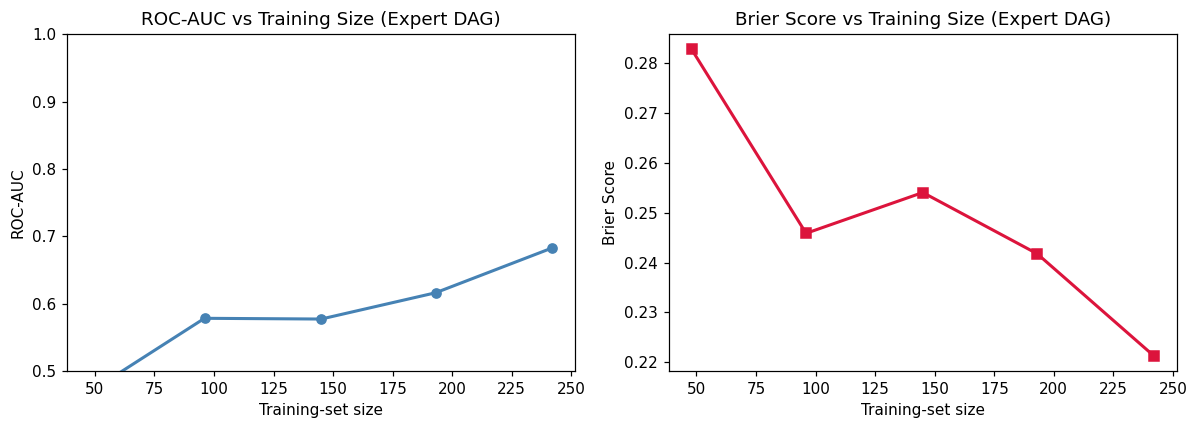

In [10]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
size_aucs, size_briers = [], []
bdeu = DiscreteBayesianEstimator(prior_type='BDeu', equivalent_sample_size=5)

for frac in fractions:
    n = max(10, int(frac * len(train_df)))
    sub = train_df.sample(n=n, random_state=SEED)
    m = DiscreteBayesianNetwork(EXPERT_EDGES)
    m = m.fit(sub, estimator=bdeu)
    proba = predict_proba_bn(m, test_df)
    size_aucs.append(roc_auc_score(y_test, proba))
    size_briers.append(brier_score_loss(y_test, proba))
    print(f'  frac={frac:.1f}  n={n}  AUC={size_aucs[-1]:.3f}  Brier={size_briers[-1]:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ns = [max(10, int(f * len(train_df))) for f in fractions]
ax1.plot(ns, size_aucs, 'o-', color='steelblue', lw=2)
ax1.set_xlabel('Training-set size'); ax1.set_ylabel('ROC-AUC')
ax1.set_title('ROC-AUC vs Training Size (Expert DAG)')
ax1.set_ylim(0.5, 1.0)

ax2.plot(ns, size_briers, 's-', color='crimson', lw=2)
ax2.set_xlabel('Training-set size'); ax2.set_ylabel('Brier Score')
ax2.set_title('Brier Score vs Training Size (Expert DAG)')

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. Interpretation — edge agreement with known risk factors

In [11]:
expert_edges_set  = set(tuple(e) for e in expert_model.edges())
learned_edges_set = set(tuple(e) for e in learned_model.edges())

shared   = expert_edges_set & learned_edges_set
only_exp = expert_edges_set - learned_edges_set
only_lrn = learned_edges_set - expert_edges_set

print(f'Shared edges ({len(shared)}):       {sorted(shared)}')
print(f'Expert-only  ({len(only_exp)}): {sorted(only_exp)}')
print(f'Learned-only ({len(only_lrn)}): {sorted(only_lrn)}')

# Highlight edges into target
print('\nEdges into "target" in expert model:')
for u, v in sorted(expert_edges_set):
    if v == 'target':
        shared_flag = '(shared)' if (u, v) in learned_edges_set else '(expert-only)'
        print(f'  {u:12s} → target  {shared_flag}')

Shared edges (2):       [('cp', 'target'), ('thalach', 'exang')]
Expert-only  (15): [('age', 'chol'), ('age', 'thalach'), ('age', 'trestbps'), ('ca', 'target'), ('chol', 'target'), ('exang', 'target'), ('fbs', 'chol'), ('oldpeak', 'target'), ('restecg', 'target'), ('sex', 'chol'), ('sex', 'thalach'), ('slope', 'oldpeak'), ('thal', 'target'), ('trestbps', 'restecg'), ('trestbps', 'target')]
Learned-only (6): [('oldpeak', 'slope'), ('oldpeak', 'thalach'), ('target', 'ca'), ('target', 'exang'), ('target', 'oldpeak'), ('target', 'thal')]

Edges into "target" in expert model:
  ca           → target  (expert-only)
  chol         → target  (expert-only)
  cp           → target  (shared)
  exang        → target  (expert-only)
  oldpeak      → target  (expert-only)
  restecg      → target  (expert-only)
  thal         → target  (expert-only)
  trestbps     → target  (expert-only)


## 11. Summary table

In [12]:
summary = pd.DataFrame([
    {'Model': 'Expert DAG',
     'Accuracy (test)':  f"{r_expert['acc']:.3f}",
     'ROC-AUC (test)':   f"{r_expert['auc']:.3f}",
     'Brier (test)':     f"{r_expert['brier']:.3f}",
     'CV AUC (5-fold)':  f"{e_auc.mean():.3f}±{e_auc.std():.3f}"},
    {'Model': 'Learned DAG (HC/BIC)',
     'Accuracy (test)':  f"{r_learned['acc']:.3f}",
     'ROC-AUC (test)':   f"{r_learned['auc']:.3f}",
     'Brier (test)':     f"{r_learned['brier']:.3f}",
     'CV AUC (5-fold)':  f"{l_auc.mean():.3f}±{l_auc.std():.3f}"},
])
print(summary.to_string(index=False))

               Model Accuracy (test) ROC-AUC (test) Brier (test) CV AUC (5-fold)
          Expert DAG           0.574          0.683        0.221     0.664±0.062
Learned DAG (HC/BIC)           0.869          0.919        0.110     0.904±0.049
